# 01 — Data Understanding

**Project:** Advanced E-Commerce Customer & Revenue Intelligence Platform
**Phase 2 (part 2):** raw data inspection and data-quality audit
**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle `olistbr/brazilian-ecommerce`), 9 CSVs

## Purpose

Before any cleaning, modelling or business claim, establish what the raw data actually
contains and where it cannot be trusted. This notebook is a **read-only audit** — it does
not modify or write any data. Every number below is computed from the raw CSVs in
`data/raw/olist/`.

## What is audited

1. Table inventory — rows, columns, memory
2. Schema and dtypes
3. Missing values (count and %)
4. Duplicates — exact rows and business-key grain
5. Entity counts and key cardinality (`customer_id` vs `customer_unique_id`)
6. Date coverage and monthly volume
7. Referential integrity across tables
8. Value-level sanity (prices, freight, payments, scores, dimensions)
9. Order lifecycle timeline logic
10. Payment vs item-total reconciliation
11. Product category naming and translation coverage
12. Geography consistency
13. A consolidated data-quality issue register

## Structural limitations of this dataset (stated up front, not worked around)

These are properties of the source data. Later phases adapt to them and label findings
accordingly rather than approximating past them:

- **No cost or margin data.** Only `price` and `freight_value` are present. True profit
  analysis is impossible; product "profitability" is scoped to revenue, price level and
  revenue concentration.
- **No marketing channel data.** No campaigns, impressions, clicks, spend or attribution.
  The marketing phase uses available proxies (payment type, seller, region, category) and
  must state that multi-channel attribution cannot be done with this data.
- **No experiment or control flag.** The A/B phase uses a natural quasi-experiment
  (e.g. payment type, or single- vs multi-item orders) and is labelled **observational**,
  not a randomised experiment.
- **No customer demographics** beyond geography (city / state / zip prefix).
- **`customer_id` is order-scoped.** It identifies a customer *account row per order*.
  `customer_unique_id` identifies the actual person across repeat orders and is the key
  used for RFM, repeat-purchase and cohort work.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# --- chart styling -------------------------------------------------------
# Single-hue palette; one series per chart, so the title names the series and
# no legend is required. Grid and axes stay recessive.
BLUE       = "#2a78d6"
BLUE_LIGHT = "#9ec5f4"
ORANGE     = "#eb6834"
INK        = "#0b0b0b"
INK_2      = "#52514e"
SURFACE    = "#fcfcfb"
GRID       = "#e3e2de"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "font.size": 10,
    "figure.dpi": 110,
})

RAW = Path("..") / "data" / "raw" / "olist"
assert RAW.exists(), f"Raw data folder not found at {RAW.resolve()}"
print("Reading from:", RAW.resolve())

Reading from: C:\Users\Omkar\OneDrive\Documents\data analysis\ecommerce-analytics\data\raw\olist


## 1. Load the raw tables

All 9 CSVs are loaded **as-is** — no dtype coercion, no date parsing, no cleaning — so that
the audit reflects the raw file contents. Dates are parsed only inside the checks that need
them.

In [2]:
FILES = {
    "orders":               "olist_orders_dataset.csv",
    "order_items":          "olist_order_items_dataset.csv",
    "customers":            "olist_customers_dataset.csv",
    "products":             "olist_products_dataset.csv",
    "payments":             "olist_order_payments_dataset.csv",
    "reviews":              "olist_order_reviews_dataset.csv",
    "sellers":              "olist_sellers_dataset.csv",
    "geolocation":          "olist_geolocation_dataset.csv",
    "category_translation": "product_category_name_translation.csv",
}

raw = {name: pd.read_csv(RAW / fname) for name, fname in FILES.items()}

# convenience handles
orders   = raw["orders"]
items    = raw["order_items"]
customers= raw["customers"]
products = raw["products"]
payments = raw["payments"]
reviews  = raw["reviews"]
sellers  = raw["sellers"]
geo      = raw["geolocation"]
trans    = raw["category_translation"]

print(f"Loaded {len(raw)} tables")

Loaded 9 tables


## 2. Table inventory

Row counts, column counts and file size for each table.

In [3]:
inventory = pd.DataFrame([
    {
        "table": name,
        "file": FILES[name],
        "rows": len(df),
        "columns": df.shape[1],
        "file_size_mb": round((RAW / FILES[name]).stat().st_size / 1024**2, 2),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
    }
    for name, df in raw.items()
]).sort_values("rows", ascending=False).reset_index(drop=True)

display(inventory)
print(f"Total rows across all tables: {inventory['rows'].sum():,}")

,table,file,rows,columns,file_size_mb,memory_mb
0,geolocation,olist_geolocation_dataset.csv,1000163,5,58.44,129.38
1,order_items,olist_order_items_dataset.csv,112650,7,14.72,35.99
2,payments,olist_order_payments_dataset.csv,103886,5,5.51,16.23
3,orders,olist_orders_dataset.csv,99441,8,16.84,52.94
4,customers,olist_customers_dataset.csv,99441,5,8.62,26.59
5,reviews,olist_order_reviews_dataset.csv,99224,7,13.78,39.12
6,products,olist_products_dataset.csv,32951,9,2.27,6.30
7,sellers,olist_sellers_dataset.csv,3095,4,0.17,0.59
8,category_translation,product_category_name_translation.csv,71,2,0.00,0.01


Total rows across all tables: 1,550,922


## 3. Schema and dtypes

Every column, its pandas dtype and its non-null count. Note that all timestamps arrive as
`object` (string) — no date type is inferred by `read_csv` — so date handling is entirely a
Phase 3 responsibility.

In [4]:
schema = pd.concat(
    [
        pd.DataFrame({
            "table": name,
            "column": df.columns,
            "dtype": df.dtypes.astype(str).values,
            "non_null": df.notna().sum().values,
            "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
        })
        for name, df in raw.items()
    ],
    ignore_index=True,
)

for name in raw:
    print("=" * 78)
    print(f"{name}  —  {raw[name].shape[0]:,} rows x {raw[name].shape[1]} cols")
    print("=" * 78)
    display(schema[schema.table == name].drop(columns="table").reset_index(drop=True))

orders  —  99,441 rows x 8 cols


,column,dtype,non_null,n_unique
0,order_id,object,99441,99441
1,customer_id,object,99441,99441
2,order_status,object,99441,8
3,order_purchase_timestamp,object,99441,98875
4,order_approved_at,object,99281,90733
5,order_delivered_carrier_date,object,97658,81018
6,order_delivered_customer_date,object,96476,95664
7,order_estimated_delivery_date,object,99441,459


order_items  —  112,650 rows x 7 cols


,column,dtype,non_null,n_unique
0,order_id,object,112650,98666
1,order_item_id,int64,112650,21
2,product_id,object,112650,32951
3,seller_id,object,112650,3095
4,shipping_limit_date,object,112650,93318
5,price,float64,112650,5968
6,freight_value,float64,112650,6999


customers  —  99,441 rows x 5 cols


...

,column,dtype,non_null,n_unique
0,seller_id,object,3095,3095
1,seller_zip_code_prefix,int64,3095,2246
2,seller_city,object,3095,611
3,seller_state,object,3095,23


geolocation  —  1,000,163 rows x 5 cols


,column,dtype,non_null,n_unique
0,geolocation_zip_code_prefix,int64,1000163,19015
1,geolocation_lat,float64,1000163,717360
2,geolocation_lng,float64,1000163,717613
3,geolocation_city,object,1000163,8011
4,geolocation_state,object,1000163,27


category_translation  —  71 rows x 2 cols


,column,dtype,non_null,n_unique
0,product_category_name,object,71,71
1,product_category_name_english,object,71,71


## 4. Missing values

Count and percentage of nulls, for every column that has at least one.

In [5]:
miss_rows = []
for name, df in raw.items():
    n = len(df)
    for col in df.columns:
        cnt = int(df[col].isna().sum())
        if cnt:
            miss_rows.append({
                "table": name, "column": col,
                "missing": cnt, "missing_pct": round(cnt / n * 100, 2), "rows": n,
            })

missing = pd.DataFrame(miss_rows).sort_values("missing_pct", ascending=False).reset_index(drop=True)
display(missing)

clean_tables = [n for n in raw if n not in set(missing.table)]
print("Tables with zero missing values:", ", ".join(clean_tables))

,table,column,missing,missing_pct,rows
0,reviews,review_comment_title,87656,88.34,99224
1,reviews,review_comment_message,58247,58.70,99224
2,orders,order_delivered_customer_date,2965,2.98,99441
3,products,product_name_lenght,610,1.85,32951
4,products,product_category_name,610,1.85,32951
5,products,product_description_lenght,610,1.85,32951
6,products,product_photos_qty,610,1.85,32951
7,orders,order_delivered_carrier_date,1783,1.79,99441
8,orders,order_approved_at,160,0.16,99441
9,products,product_length_cm,2,0.01,32951


Tables with zero missing values: order_items, customers, payments, sellers, geolocation, category_translation


findfont: Failed to find font weight 600, now using 700.


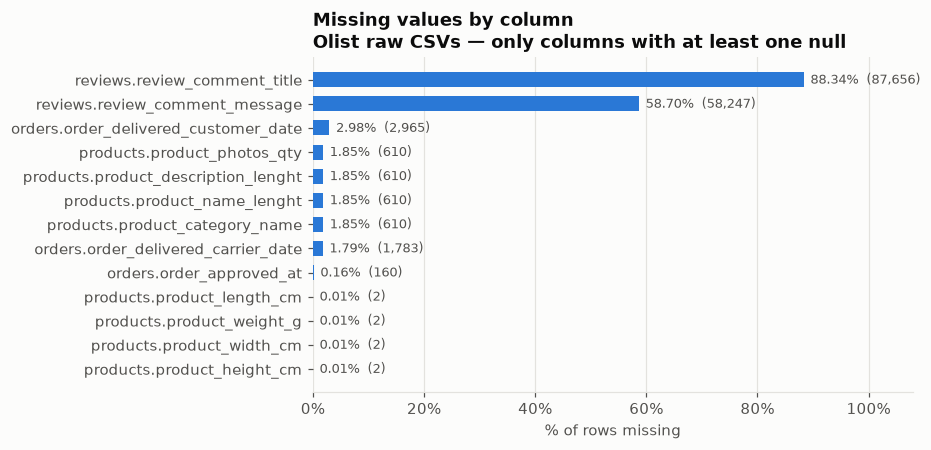

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))

d = missing.sort_values("missing_pct")
labels = d.table + "." + d.column
bars = ax.barh(labels, d.missing_pct, color=BLUE, height=0.62)

for bar, pct, cnt in zip(bars, d.missing_pct, d.missing):
    ax.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
            f"{pct:.2f}%  ({cnt:,})", va="center", ha="left", fontsize=8.5, color=INK_2)

ax.set_title("Missing values by column\nOlist raw CSVs — only columns with at least one null")
ax.set_xlabel("% of rows missing")
ax.set_xlim(0, 108)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.grid(axis="y", visible=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Reading this chart.** The two review-comment columns are mostly empty by design — free-text
review fields are optional, so their nulls mean "customer left no comment", not corrupted data.
The `orders` date nulls and the `products` attribute nulls are the ones that carry analytical
consequences; both are diagnosed further below.

## 5. Duplicates

Two separate questions: (a) fully identical rows, and (b) duplicates at the table's intended
business-key grain — a table can have zero identical rows yet still violate its key.

In [7]:
GRAIN = {
    "orders":               ["order_id"],
    "order_items":          ["order_id", "order_item_id"],
    "customers":            ["customer_id"],
    "products":             ["product_id"],
    "payments":             ["order_id", "payment_sequential"],
    "reviews":              ["review_id"],
    "sellers":              ["seller_id"],
    "geolocation":          None,   # no declared key — one row per lat/lng observation
    "category_translation": ["product_category_name"],
}

dup_rows = []
for name, df in raw.items():
    keys = GRAIN[name]
    dup_rows.append({
        "table": name,
        "rows": len(df),
        "exact_dup_rows": int(df.duplicated().sum()),
        "exact_dup_pct": round(df.duplicated().sum() / len(df) * 100, 2),
        "declared_grain": ", ".join(keys) if keys else "(none)",
        "dup_on_grain": int(df.duplicated(keys).sum()) if keys else np.nan,
    })

display(pd.DataFrame(dup_rows))

,table,rows,exact_dup_rows,exact_dup_pct,declared_grain,dup_on_grain
0,orders,99441,0,0.00,order_id,0.00
1,order_items,112650,0,0.00,"order_id, order_item_id",0.00
2,customers,99441,0,0.00,customer_id,0.00
3,products,32951,0,0.00,product_id,0.00
4,payments,103886,0,0.00,"order_id, payment_sequential",0.00
5,reviews,99224,0,0.00,review_id,814.00
6,sellers,3095,0,0.00,seller_id,0.00
7,geolocation,1000163,261831,26.18,(none),NaN
8,category_translation,71,0,0.00,product_category_name,0.00


In [8]:
# reviews is the one table whose key genuinely breaks — inspect it
rev_id_dupes  = reviews.review_id.value_counts()
ord_id_dupes  = reviews.order_id.value_counts()

print(f"reviews rows                      : {len(reviews):,}")
print(f"distinct review_id                : {reviews.review_id.nunique():,}")
print(f"review_id values appearing >1     : {(rev_id_dupes > 1).sum():,}  "
      f"(rows involved: {reviews.duplicated('review_id', keep=False).sum():,})")
print(f"distinct order_id                 : {reviews.order_id.nunique():,}")
print(f"order_id values appearing >1      : {(ord_id_dupes > 1).sum():,}  "
      f"(rows involved: {reviews.duplicated('order_id', keep=False).sum():,})")

multi = reviews[reviews.order_id.isin(ord_id_dupes[ord_id_dupes > 1].index)]
conflict = multi.groupby("order_id").review_score.nunique()
print(f"\norders carrying >1 review         : {len(conflict):,}")
print(f"  ...with CONFLICTING scores      : {int((conflict > 1).sum()):,}")
print(f"  ...with consistent scores       : {int((conflict == 1).sum()):,}")

print("\nExample of one review_id attached to two different orders:")
ex = rev_id_dupes[rev_id_dupes > 1].index[0]
display(reviews[reviews.review_id == ex][
    ["review_id", "order_id", "review_score", "review_creation_date"]])

reviews rows                      : 99,224
distinct review_id                : 98,410
review_id values appearing >1     : 789  (rows involved: 1,603)
distinct order_id                 : 98,673
order_id values appearing >1      : 547  (rows involved: 1,098)

orders carrying >1 review         : 547
  ...with CONFLICTING scores      : 202
  ...with consistent scores       : 345

Example of one review_id attached to two different orders:


,review_id,order_id,review_score,review_creation_date
8404,08528f70f579f0c830189efc523d2182,7813842ae95e8c497fc0233232ae815a,1,2018-08-03 00:00:00
39950,08528f70f579f0c830189efc523d2182,03310aa823a66056268a3bab36e827fb,1,2018-08-03 00:00:00
74820,08528f70f579f0c830189efc523d2182,53c71d3953507c6239ff73917ed358c9,1,2018-08-03 00:00:00


**Finding.** `review_id` is **not** a primary key: 789 ids repeat, and `order_id` is not unique
either — 547 orders carry more than one review row, 202 of them with *conflicting* scores. Any
join from orders to reviews must therefore deduplicate deliberately (one review per order, by a
stated rule) or it will silently inflate order-level revenue through fan-out.

`geolocation` has 261,831 fully identical rows (26% of the table). That is expected — it is a
zip-prefix → coordinate lookup with one row per observation, not per location — but it means the
table must be collapsed to one row per zip prefix before any join, or it will multiply rows
enormously.

## 6. Entity counts and key cardinality

The single most consequential modelling fact in this dataset: **`customer_id` is order-scoped.**
It is issued per order, so it can never show a repeat purchase. `customer_unique_id` is the
person.

In [9]:
print("ORDERS")
print(f"  rows                         : {len(orders):,}")
print(f"  distinct order_id            : {orders.order_id.nunique():,}")
print(f"  distinct customer_id         : {orders.customer_id.nunique():,}")

print("\nCUSTOMERS")
print(f"  rows                         : {len(customers):,}")
print(f"  distinct customer_id         : {customers.customer_id.nunique():,}   <- order-scoped")
print(f"  distinct customer_unique_id  : {customers.customer_unique_id.nunique():,}   <- actual people")
print(f"  difference                   : {len(customers) - customers.customer_unique_id.nunique():,}"
      "   (repeat-order accounts collapsed)")

per_person = customers.customer_unique_id.value_counts()
repeat = int((per_person > 1).sum())
print("\nREPEAT BEHAVIOUR (by customer_unique_id)")
print(f"  people with >1 order         : {repeat:,} of {len(per_person):,}")
print(f"  repeat-customer rate         : {repeat / len(per_person) * 100:.2f}%")
print(f"  max orders by one person     : {per_person.max()}")
display(per_person.value_counts().sort_index().rename("people").to_frame()
        .rename_axis("orders_placed").head(8))

print("\nOTHER ENTITIES")
print(f"  distinct products (products) : {products.product_id.nunique():,}")
print(f"  distinct products (in items) : {items.product_id.nunique():,}")
print(f"  distinct sellers (sellers)   : {sellers.seller_id.nunique():,}")
print(f"  distinct sellers (in items)  : {items.seller_id.nunique():,}")
print(f"  distinct orders in items     : {items.order_id.nunique():,}")
print(f"  distinct orders in payments  : {payments.order_id.nunique():,}")
print(f"  distinct product categories  : {products.product_category_name.nunique():,}")

ORDERS
  rows                         : 99,441
  distinct order_id            : 99,441
  distinct customer_id         : 99,441

CUSTOMERS
  rows                         : 99,441
  distinct customer_id         : 99,441   <- order-scoped
  distinct customer_unique_id  : 96,096   <- actual people
  difference                   : 3,345   (repeat-order accounts collapsed)

REPEAT BEHAVIOUR (by customer_unique_id)
  people with >1 order         : 2,997 of 96,096
  repeat-customer rate         : 3.12%
  max orders by one person     : 17


,people
orders_placed,
1,93099
2,2745
3,203
4,30
5,8
6,6
7,3
9,1



OTHER ENTITIES
  distinct products (products) : 32,951
  distinct products (in items) : 32,951
  distinct sellers (sellers)   : 3,095
  distinct sellers (in items)  : 3,095
  distinct orders in items     : 98,666
  distinct orders in payments  : 99,440
  distinct product categories  : 73


**Finding.** 99,441 `customer_id` values collapse to **96,096 real people**. Using `customer_id`
for customer analytics would report a 0% repeat rate by construction. The true repeat rate is
**3.12%** (2,997 people), with one customer placing 17 orders. That is a low repeat base, and it
directly constrains Phases 4–6: RFM frequency will be near-degenerate (almost everyone F=1),
cohort retention curves will be shallow, and "churn" must be framed as one-time-buyer dominance
rather than classical subscription churn.

## 7. Date coverage

Range of every timestamp column, plus monthly order volume — which reveals how usable the edges
of the window are.

In [10]:
DATE_COLS = {
    "orders": ["order_purchase_timestamp", "order_approved_at",
               "order_delivered_carrier_date", "order_delivered_customer_date",
               "order_estimated_delivery_date"],
    "order_items": ["shipping_limit_date"],
    "reviews": ["review_creation_date", "review_answer_timestamp"],
}

rows = []
for tbl, cols in DATE_COLS.items():
    df = raw[tbl]
    for c in cols:
        parsed = pd.to_datetime(df[c], errors="coerce")
        rows.append({
            "table": tbl, "column": c,
            "min": parsed.min(), "max": parsed.max(),
            "null": int(df[c].isna().sum()),
            "unparseable": int(parsed.isna().sum() - df[c].isna().sum()),
        })

display(pd.DataFrame(rows))

,table,column,min,max,null,unparseable
0,orders,order_purchase_timestamp,2016-09-04 21:15:19,2018-10-17 17:30:18,0,0
1,orders,order_approved_at,2016-09-15 12:16:38,2018-09-03 17:40:06,160,0
2,orders,order_delivered_carrier_date,2016-10-08 10:34:01,2018-09-11 19:48:28,1783,0
3,orders,order_delivered_customer_date,2016-10-11 13:46:32,2018-10-17 13:22:46,2965,0
4,orders,order_estimated_delivery_date,2016-09-30 00:00:00,2018-11-12 00:00:00,0,0
5,order_items,shipping_limit_date,2016-09-19 00:15:34,2020-04-09 22:35:08,0,0
6,reviews,review_creation_date,2016-10-02 00:00:00,2018-08-31 00:00:00,0,0
7,reviews,review_answer_timestamp,2016-10-07 18:32:28,2018-10-29 12:27:35,0,0


In [11]:
o = orders.copy()
o["purchase_ts"] = pd.to_datetime(o.order_purchase_timestamp)
monthly = o.groupby(o.purchase_ts.dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()

print("Monthly order counts:")
display(monthly.rename("orders").to_frame().T)

Monthly order counts:


purchase_ts,2016-09-01,2016-10-01,2016-12-01,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01
orders,4,324,1,800,1780,2682,2404,3700,3245,4026,4331,4285,4631,7544,5673,7269,6728,7211,6939,6873,6167,6292,6512,16,4


C:\Users\Omkar\AppData\Local\Temp\ipykernel_27556\1178876234.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  ax.axvspan(pd.Timestamp("2018-09-01"), monthly.index[-1] + pd.Timedelta(days=20),


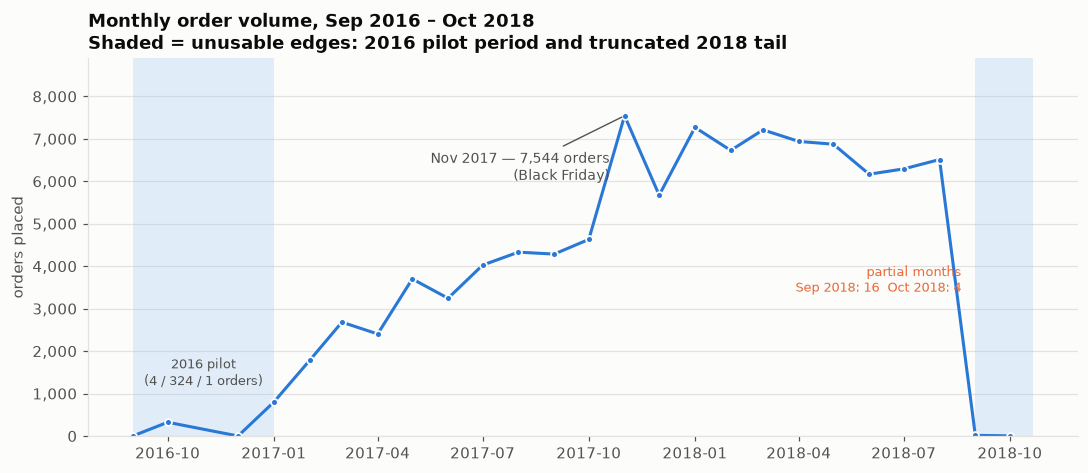

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.4))

ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2,
        marker="o", markersize=4.5, markerfacecolor=BLUE,
        markeredgecolor=SURFACE, markeredgewidth=1.2)

# shade the two unusable edges
ax.axvspan(monthly.index[0], pd.Timestamp("2017-01-01"), color=BLUE_LIGHT, alpha=0.28, lw=0)
ax.axvspan(pd.Timestamp("2018-09-01"), monthly.index[-1] + pd.Timedelta(days=20),
           color=BLUE_LIGHT, alpha=0.28, lw=0)

peak = monthly.idxmax()
ax.annotate(f"Nov 2017 — {monthly.max():,} orders\n(Black Friday)",
            xy=(peak, monthly.max()), xytext=(-10, -42), textcoords="offset points",
            fontsize=9, color=INK_2, ha="right",
            arrowprops=dict(arrowstyle="-", color=INK_2, lw=0.9))
ax.annotate("2016 pilot\n(4 / 324 / 1 orders)", xy=(pd.Timestamp("2016-11-01"), 1200),
            fontsize=8.5, color=INK_2, ha="center")
ax.annotate(f"partial months\nSep 2018: {monthly.iloc[-2]:,}  Oct 2018: {monthly.iloc[-1]:,}",
            xy=(pd.Timestamp("2018-08-20"), 3400), fontsize=8.5, color=ORANGE, ha="right")

ax.set_title("Monthly order volume, Sep 2016 – Oct 2018\nShaded = unusable edges: 2016 pilot period and truncated 2018 tail")
ax.set_ylabel("orders placed")
ax.set_ylim(0, monthly.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Finding — the analysis window is narrower than the file's date range.** Purchases span
2016-09-04 to 2018-10-17, but that full range is misleading:

- **2016 is a pilot period**: 4 orders in Sep, 324 in Oct, 1 in Dec, and *nothing in Nov 2016* —
  a genuine gap, not a null.
- **The tail is truncated**: Sep 2018 has 16 orders and Oct 2018 has 4, against ~6,500/month in
  the preceding months. These are not a demand collapse; the extract simply stops.

The forecasting phase (Phase 10) must therefore fit on roughly **Jan 2017 – Aug 2018 (20 months)**
and explicitly drop the partial edges. 20 monthly points is a short series — enough for naive,
moving-average and exponential-smoothing baselines, and borderline for seasonal ARIMA, since it
gives fewer than two full annual cycles. That constraint will be stated in the forecast rather
than hidden.

Also note `shipping_limit_date` reaches **2020-04-09**, far beyond the order window — 4 item rows
carry dates 18 months after the last purchase. These are data errors, not future shipments.

## 8. Referential integrity

Whether every foreign key resolves, and — just as important — which parent rows have **no**
children (orders with no items, no payment, no review).

In [13]:
checks = [
    ("orders.customer_id -> customers",  (~orders.customer_id.isin(customers.customer_id)).sum(), len(orders)),
    ("order_items.order_id -> orders",   (~items.order_id.isin(orders.order_id)).sum(), len(items)),
    ("order_items.product_id -> products", (~items.product_id.isin(products.product_id)).sum(), len(items)),
    ("order_items.seller_id -> sellers", (~items.seller_id.isin(sellers.seller_id)).sum(), len(items)),
    ("payments.order_id -> orders",      (~payments.order_id.isin(orders.order_id)).sum(), len(payments)),
    ("reviews.order_id -> orders",       (~reviews.order_id.isin(orders.order_id)).sum(), len(reviews)),
    ("products.category -> translation", products[products.product_category_name.notna()]
         .product_category_name.isin(trans.product_category_name).eq(False).sum(),
     int(products.product_category_name.notna().sum())),
]
fk = pd.DataFrame(checks, columns=["foreign_key", "orphans", "rows_checked"])
fk["orphan_pct"] = (fk.orphans / fk.rows_checked * 100).round(3)
print("ORPHANED FOREIGN KEYS (child rows whose parent is missing)")
display(fk)

ORPHANED FOREIGN KEYS (child rows whose parent is missing)


,foreign_key,orphans,rows_checked,orphan_pct
0,orders.customer_id -> customers,0,99441,0.00
1,order_items.order_id -> orders,0,112650,0.00
2,order_items.product_id -> products,0,112650,0.00
3,order_items.seller_id -> sellers,0,112650,0.00
4,payments.order_id -> orders,0,103886,0.00
5,reviews.order_id -> orders,0,99224,0.00
6,products.category -> translation,13,32341,0.04


In [14]:
print("CHILDLESS PARENTS (orders missing an expected child record)")
no_items  = orders[~orders.order_id.isin(items.order_id)]
no_pay    = orders[~orders.order_id.isin(payments.order_id)]
no_review = orders[~orders.order_id.isin(reviews.order_id)]

print(f"\norders with NO order_items : {len(no_items):,}  ({len(no_items)/len(orders)*100:.2f}%)")
display(no_items.order_status.value_counts().rename("orders").to_frame())

print(f"orders with NO payment     : {len(no_pay):,}")
display(no_pay[["order_id", "order_status", "order_purchase_timestamp"]])

print(f"orders with NO review      : {len(no_review):,}  ({len(no_review)/len(orders)*100:.2f}%)")
display(no_review.order_status.value_counts().rename("orders").to_frame())

CHILDLESS PARENTS (orders missing an expected child record)

orders with NO order_items : 775  (0.78%)


,orders
order_status,
unavailable,603
canceled,164
created,5
invoiced,2
shipped,1


orders with NO payment     : 1


,order_id,order_status,order_purchase_timestamp
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38


orders with NO review      : 768  (0.77%)


,orders
order_status,
delivered,646
shipped,75
canceled,20
unavailable,14
processing,6
invoiced,5
created,2


**Finding.** All foreign keys resolve — **zero orphans** in every direction. The integrity
problems are on the other side: rows that exist without their expected children.

- **775 orders have no line items** (0.78%). These are overwhelmingly `unavailable` (603) and
  `canceled` (164) — i.e. they are legitimately item-less, not broken joins. They contribute zero
  revenue and will drop out naturally on an inner join to `order_items`.
- **1 delivered order has no payment record at all** — a genuine gap; that order's revenue is
  unrecoverable from the payments table.
- **768 orders have no review** (0.77%), which is simply non-response.
- **Two product categories have no English translation** (`pc_gamer`,
  `portateis_cozinha_e_preparadores_de_alimentos`): the products table has 73 distinct categories,
  the translation table only 71. A naive inner join on the translation would silently delete
  those two categories from every product report.

## 9. Value-level sanity checks

Do the numeric and categorical values fall in ranges that make business sense?

In [15]:
print("ORDER STATUS")
display(orders.order_status.value_counts().rename("orders").to_frame()
        .assign(pct=lambda d: (d.orders / len(orders) * 100).round(2)))

print("MONETARY COLUMNS")
display(pd.DataFrame({
    "order_items.price": items.price.describe(),
    "order_items.freight_value": items.freight_value.describe(),
    "payments.payment_value": payments.payment_value.describe(),
}))

print(f"price <= 0                 : {int((items.price <= 0).sum())}")
print(f"freight_value < 0          : {int((items.freight_value < 0).sum())}")
print(f"freight_value == 0         : {int((items.freight_value == 0).sum())}  (free shipping)")
print(f"payment_value <= 0         : {int((payments.payment_value <= 0).sum())}")

ORDER STATUS


,orders,pct
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


MONETARY COLUMNS


,order_items.price,order_items.freight_value,payments.payment_value
count,"112,650.00","112,650.00","103,886.00"
mean,120.65,19.99,154.10
std,183.63,15.81,217.49
min,0.85,0.00,0.00
25%,39.90,13.08,56.79
50%,74.99,16.26,100.00
75%,134.90,21.15,171.84
max,"6,735.00",409.68,"13,664.08"


price <= 0                 : 0
freight_value < 0          : 0
freight_value == 0         : 383  (free shipping)
payment_value <= 0         : 9


In [16]:
print("PAYMENT TYPE")
display(payments.payment_type.value_counts().rename("rows").to_frame()
        .assign(pct=lambda d: (d.rows / len(payments) * 100).round(2)))

print("PAYMENT INSTALLMENTS")
print(f"  range: {payments.payment_installments.min()} – {payments.payment_installments.max()}")
print(f"  rows with 0 installments: {int((payments.payment_installments == 0).sum())}")
display(payments[payments.payment_installments == 0])

print("\nREVIEW SCORES")
display(reviews.review_score.value_counts().sort_index().rename("reviews").to_frame()
        .assign(pct=lambda d: (d.reviews / len(reviews) * 100).round(2)))

print("\nPRODUCT PHYSICAL ATTRIBUTES")
dims = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
display(pd.DataFrame({
    "min": products[dims].min(), "max": products[dims].max(),
    "zeros": (products[dims] == 0).sum(), "nulls": products[dims].isna().sum(),
}))

PAYMENT TYPE


,rows,pct
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00


PAYMENT INSTALLMENTS
  range: 0 – 24
  rows with 0 installments: 2


,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94



REVIEW SCORES


,reviews,pct
review_score,,
1,11424,11.51
2,3151,3.18
3,8179,8.24
4,19142,19.29
5,57328,57.78



PRODUCT PHYSICAL ATTRIBUTES


,min,max,zeros,nulls
product_weight_g,0.00,"40,425.00",4,2
product_length_cm,7.00,105.00,0,2
product_height_cm,2.00,105.00,0,2
product_width_cm,6.00,118.00,0,2


**Finding.** Monetary values are clean in sign: **no negative or zero prices**, no negative
freight. The exceptions are narrow and worth naming:

- **9 payment rows have `payment_value = 0`** and **3 rows have `payment_type = 'not_defined'`** —
  these coincide and look like voided/placeholder payment records.
- **2 payment rows record 0 installments**, which is not a valid installment count.
- **383 item rows have zero freight** — legitimate free shipping, not an error.
- **4 products have `product_weight_g = 0`**, impossible for a physical good.
- **Review scores are strongly bimodal**: 57.8% are 5-star but 11.5% are 1-star, with few 2s.
  Any mean-score metric will be misleading; satisfaction analysis should use the distribution or
  a top-box / bottom-box rate.
- **Order status is dominated by `delivered` (97.0%)**. The 2,963 non-delivered orders
  (shipped, canceled, unavailable, invoiced, processing, created, approved) must be excluded from
  revenue by an explicit rule, since a canceled order still carries a price in `order_items`.

## 10. Order lifecycle timeline logic

The order timeline should run purchase → approved → handed to carrier → delivered. Violations
indicate timestamp errors rather than real sequences.

In [17]:
o = orders.copy()
for c in DATE_COLS["orders"]:
    o[c] = pd.to_datetime(o[c], errors="coerce")

viol = pd.DataFrame([
    ("approved before purchase",          int((o.order_approved_at < o.order_purchase_timestamp).sum())),
    ("carrier pickup before approval",    int((o.order_delivered_carrier_date < o.order_approved_at).sum())),
    ("delivered before carrier pickup",   int((o.order_delivered_customer_date < o.order_delivered_carrier_date).sum())),
    ("delivered before purchase",         int((o.order_delivered_customer_date < o.order_purchase_timestamp).sum())),
], columns=["rule_violated", "orders"])
display(viol)

delivered = o[o.order_status == "delivered"]
print("STATUS vs TIMESTAMP CONSISTENCY")
print(f"  status='delivered' but no delivery date : {int(delivered.order_delivered_customer_date.isna().sum())}")
print(f"  status='delivered' but no approved_at   : {int(delivered.order_approved_at.isna().sum())}")
print(f"  status!='delivered' but HAS delivery date:")
display(o[(o.order_status != "delivered") & o.order_delivered_customer_date.notna()]
        .order_status.value_counts().rename("orders").to_frame())

late = (o.order_delivered_customer_date > o.order_estimated_delivery_date)
print(f"\nDELIVERY PERFORMANCE (delivered orders with both dates)")
base = o.order_delivered_customer_date.notna() & o.order_estimated_delivery_date.notna()
print(f"  delivered later than estimate : {int(late.sum()):,} of {int(base.sum()):,} "
      f"({late.sum()/base.sum()*100:.2f}%)")
days = (o.order_delivered_customer_date - o.order_purchase_timestamp).dt.total_seconds() / 86400
print(f"  purchase->delivery days: median {days.median():.1f}, mean {days.mean():.1f}, max {days.max():.0f}")

,rule_violated,orders
0,approved before purchase,0
1,carrier pickup before approval,1359
2,delivered before carrier pickup,23
3,delivered before purchase,0


STATUS vs TIMESTAMP CONSISTENCY
  status='delivered' but no delivery date : 8
  status='delivered' but no approved_at   : 14
  status!='delivered' but HAS delivery date:


,orders
order_status,
canceled,6



DELIVERY PERFORMANCE (delivered orders with both dates)
  delivered later than estimate : 7,827 of 96,476 (8.11%)


  purchase->delivery days: median 10.2, mean 12.6, max 210


**Finding.** The timeline is mostly coherent — nothing is delivered before it was purchased, and
nothing is approved before purchase. But there are real inconsistencies:

- **1,359 orders show carrier pickup before payment approval** and **23 show delivery before
  carrier pickup**. Small in share, but they mean per-stage duration metrics can go negative and
  must be guarded in Phase 3.
- **8 orders have `status = 'delivered'` with no delivery timestamp**, and **14 delivered orders
  were never approved**.
- **6 `canceled` orders carry a delivery date** — status and events disagree.
- **7,827 orders (8.1%) arrived later than the estimated delivery date.** This is a genuine
  business signal, not a data fault, and is worth carrying into the satisfaction analysis, since
  late delivery is the most plausible driver of the 1-star cluster seen above.

## 11. Payment vs item-total reconciliation

`payment_value` summed per order should equal the sum of item `price + freight_value`. Whether
the two agree decides which table is the authoritative revenue source.

In [18]:
by_order = items.groupby("order_id")[["price", "freight_value"]].sum()
by_order["item_total"] = by_order.price + by_order.freight_value
pay_order = payments.groupby("order_id").payment_value.sum()

recon = by_order.join(pay_order, how="inner")
recon["diff"] = (recon.payment_value - recon.item_total).round(2)

print(f"orders reconciled              : {len(recon):,}")
print(f"exact match (|diff| < 0.01)    : {int((recon['diff'].abs() < 0.01).sum()):,} "
      f"({(recon['diff'].abs() < 0.01).mean()*100:.2f}%)")
print(f"|diff| > R$1.00                : {int((recon['diff'].abs() > 1).sum()):,}")
print(f"|diff| > R$10.00               : {int((recon['diff'].abs() > 10).sum()):,}")
display(recon["diff"].describe().to_frame("payment_minus_items"))

print("\nLargest discrepancies:")
display(recon.reindex(recon["diff"].abs().sort_values(ascending=False).index)
        .head(5)[["item_total", "payment_value", "diff"]])

print("\nREVENUE SCALE (raw, before any cleaning rule)")
delivered_ids = set(orders.loc[orders.order_status == "delivered", "order_id"])
print(f"  item price, all orders        : R$ {items.price.sum():,.2f}")
print(f"  item price, delivered only    : R$ {items[items.order_id.isin(delivered_ids)].price.sum():,.2f}")
print(f"  freight, all orders           : R$ {items.freight_value.sum():,.2f}")
print(f"  total payment_value           : R$ {payments.payment_value.sum():,.2f}")

orders reconciled              : 98,665
exact match (|diff| < 0.01)    : 98,089 (99.42%)
|diff| > R$1.00                : 249
|diff| > R$10.00               : 98


,payment_minus_items
count,"98,665.00"
mean,0.03
std,1.13
min,-51.62
25%,0.00
50%,0.00
75%,0.00
max,182.81



Largest discrepancies:


,item_total,payment_value,diff
order_id,,,
ce6d150fb29ada17d2082f4847107665,"1,403.66","1,586.47",182.81
6e5fe7366a2e1bfbf3257dba0af1267f,287.91,406.92,119.01
70b742795bc441e94a44a084b6d9ce7a,466.93,578.82,111.89
996c7e73600ad3723e8627ab7bef81e4,587.90,664.43,76.53
70b7e94ea46d3e8b5bc12a50186edaf0,213.15,274.84,61.69



REVENUE SCALE (raw, before any cleaning rule)


  item price, all orders        : R$ 13,591,643.70
  item price, delivered only    : R$ 13,221,498.11
  freight, all orders           : R$ 2,251,909.54
  total payment_value           : R$ 16,008,872.12


**Finding.** The two sources agree for **99.4% of orders** (98,089 of 98,665 match to the cent),
so the data is internally consistent. Only 249 orders differ by more than R$1, with the gap
running from −R$51.62 to +R$182.81 — small enough not to threaten aggregate revenue, and most
likely voucher and multi-payment-method splits.

**Decision for Phase 3:** use `order_items.price` as the revenue measure and treat
`freight_value` as a separate cost-to-customer line, because item-level price is the only source
attributable to a *product, category and seller*. `payment_value` cannot be broken down below the
order. Headline revenue on delivered orders is **R$ 13.22M** of the R$ 13.59M gross.

## 12. Product category naming and translation coverage

In [19]:
print(f"distinct categories in products       : {products.product_category_name.nunique()}")
print(f"rows in translation table             : {len(trans)}")
print(f"products with NULL category           : {int(products.product_category_name.isna().sum())} "
      f"({products.product_category_name.isna().mean()*100:.2f}%)")

untranslated = sorted(set(products.product_category_name.dropna()) - set(trans.product_category_name))
print(f"\ncategories with NO English translation : {untranslated}")

unused = sorted(set(trans.product_category_name) - set(products.product_category_name.dropna()))
print(f"translations with no matching product : {unused}")

# revenue exposure of the untranslated + null categories
pi = items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
pi = pi[pi.order_id.isin(delivered_ids)]
print(f"\nrevenue in untranslated categories    : R$ {pi[pi.product_category_name.isin(untranslated)].price.sum():,.2f}")
print(f"revenue with NULL category            : R$ {pi[pi.product_category_name.isna()].price.sum():,.2f} "
      f"({pi[pi.product_category_name.isna()].price.sum()/pi.price.sum()*100:.2f}% of delivered revenue)")

print("\nTop 10 categories by delivered revenue (raw Portuguese names):")
top = (pi.groupby("product_category_name").price.agg(revenue="sum", items="count")
       .sort_values("revenue", ascending=False).head(10))
display(top)

distinct categories in products       : 73
rows in translation table             : 71
products with NULL category           : 610 (1.85%)

categories with NO English translation : ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']
translations with no matching product : []

revenue in untranslated categories    : R$ 5,240.58
revenue with NULL category            : R$ 170,726.63 (1.29% of delivered revenue)

Top 10 categories by delivered revenue (raw Portuguese names):


,revenue,items
product_category_name,,
beleza_saude,"1,233,131.72",9465
relogios_presentes,"1,166,176.98",5859
cama_mesa_banho,"1,023,434.76",10953
esporte_lazer,"954,852.55",8431
informatica_acessorios,"888,724.61",7644
moveis_decoracao,"711,927.69",8160
utilidades_domesticas,"615,628.69",6795
cool_stuff,"610,204.10",3718
automotivo,"578,966.65",4140


**Finding.** The category dimension needs a left join, not an inner one.

- **610 products (1.85%) have no category at all** — carrying **R$ 170,727** of delivered revenue
  (1.29%). That is small but non-zero; it belongs in an explicit "Unknown" bucket rather than
  being dropped.
- **Two categories are untranslated** and must be translated manually, or they will vanish from
  every English-labelled chart.
- Revenue is spread widely: the top category (`beleza_saude`, health & beauty) is R$ 1.23M of
  R$ 13.2M — about 9%. There is no single dominant category, which makes the concentration
  analysis in Phase 7 worth doing properly.

## 13. Geography consistency

In [20]:
print("GRANULARITY")
print(f"  customer states                : {customers.customer_state.nunique()}")
print(f"  customer cities (distinct)     : {customers.customer_city.nunique():,}")
print(f"  geolocation cities (distinct)  : {geo.geolocation_city.nunique():,}   <- far more spellings")
print(f"  geolocation zip prefixes       : {geo.geolocation_zip_code_prefix.nunique():,}")
print(f"  geolocation rows               : {len(geo):,}  (exact dupes: {int(geo.duplicated().sum()):,})")

print("\nZIP COVERAGE")
print(f"  customer zips not in geolocation : {int((~customers.customer_zip_code_prefix.isin(geo.geolocation_zip_code_prefix)).sum()):,}")
print(f"  seller zips not in geolocation   : {int((~sellers.seller_zip_code_prefix.isin(geo.geolocation_zip_code_prefix)).sum()):,}")
print(f"  customer cities absent from geo  : {len(set(customers.customer_city) - set(geo.geolocation_city)):,}")

print("\nCOORDINATE PLAUSIBILITY (Brazil bounding box)")
outside = geo[(geo.geolocation_lat > 5.27) | (geo.geolocation_lat < -33.75) |
              (geo.geolocation_lng > -34.79) | (geo.geolocation_lng < -73.99)]
print(f"  lat range : {geo.geolocation_lat.min():.4f} to {geo.geolocation_lat.max():.4f}")
print(f"  lng range : {geo.geolocation_lng.min():.4f} to {geo.geolocation_lng.max():.4f}")
print(f"  rows outside Brazil            : {len(outside):,} ({len(outside)/len(geo)*100:.4f}%)")

print("\nCITY NAME VARIANTS — 'sao paulo' spellings present in geolocation:")
print([c for c in geo.geolocation_city.unique() if "paulo" in str(c) and len(str(c)) < 16][:12])

print("\nORDER CONCENTRATION BY STATE")
co = orders.merge(customers, on="customer_id")
st = co.customer_state.value_counts().rename("orders").to_frame()
st["pct"] = (st.orders / len(co) * 100).round(2)
display(st.head(10))
print(f"Top 3 states account for {st.pct.head(3).sum():.1f}% of all orders")

GRANULARITY
  customer states                : 27
  customer cities (distinct)     : 4,119


  geolocation cities (distinct)  : 8,011   <- far more spellings
  geolocation zip prefixes       : 19,015


  geolocation rows               : 1,000,163  (exact dupes: 261,831)

ZIP COVERAGE
  customer zips not in geolocation : 278
  seller zips not in geolocation   : 7
  customer cities absent from geo  : 50

COORDINATE PLAUSIBILITY (Brazil bounding box)
  lat range : -36.6054 to 45.0659
  lng range : -101.4668 to 121.1054
  rows outside Brazil            : 42 (0.0042%)

CITY NAME VARIANTS — 'sao paulo' spellings present in geolocation:
['sao paulo', 'são paulo', 'sãopaulo', 'sa£o paulo', 'paulo de faria', 'monsenhor paulo', 'paulo afonso', 'frei paulo', 'paulo jacinto', 'paulo ramos', 'paulo frontin', 'paulo lopes']

ORDER CONCENTRATION BY STATE


,orders,pct
customer_state,,
SP,41746,41.98
RJ,12852,12.92
MG,11635,11.70
RS,5466,5.50
PR,5045,5.07
SC,3637,3.66
BA,3380,3.40
DF,2140,2.15
ES,2033,2.04


Top 3 states account for 66.6% of all orders


**Finding.** Geography is usable at **state and zip-prefix level, but not at city level as-is**.

- `geolocation` lists **8,011 distinct city spellings** against 4,119 in `customers` — accents,
  missing spaces and typos proliferate (`sao paulo`, `são paulo`, `sãopaulo`, `sa£o paulo`).
  City-level analysis requires normalisation; **state-level analysis is clean** (exactly 27
  Brazilian states, no junk values).
- **278 customer zip prefixes and 7 seller zip prefixes have no coordinates**, so a map built on
  an inner join would silently drop them.
- **42 rows sit outside Brazil's bounding box** (latitudes up to +45, longitudes to +121) —
  clearly corrupt coordinates to filter before mapping.
- The files themselves are **valid UTF-8**; accented names decode correctly. Only a single row
  carries genuinely corrupted text, so this is a normalisation problem, not an encoding problem.
- Demand is heavily concentrated: **São Paulo state alone is 42.0% of orders**, and the top 3
  states are 66.6%. Any regional comparison must account for this imbalance rather than comparing
  raw totals.

## 14. Data-quality issue register

Every issue found above, with its size and the decision it forces in Phase 3.

In [21]:
register = pd.DataFrame([
    ("BLOCKING", "reviews", "review_id is not unique (789 ids repeat); 547 orders have >1 review, 202 with conflicting scores",
     "Deduplicate to one review per order by an explicit rule before joining, or order revenue fans out"),
    ("BLOCKING", "geolocation", "261,831 exact duplicate rows (26%); 8,011 city spellings vs 4,119 in customers",
     "Collapse to one row per zip prefix (median lat/lng) before any join; use state, not city"),
    ("BLOCKING", "orders", "2016 is a pilot (4/324/1 orders, Nov 2016 empty); Sep-Oct 2018 truncated (16 and 4 orders)",
     "Restrict time-series and forecasting to Jan 2017 - Aug 2018 (20 months); state the limit"),
    ("BLOCKING", "customers", "customer_id is order-scoped: 99,441 ids = 96,096 people",
     "Use customer_unique_id for all RFM, cohort and repeat-purchase work"),
    ("HIGH", "orders", "2,963 orders (3.0%) are not 'delivered' but still carry item prices",
     "Define revenue on delivered orders only; state the rule in every revenue figure"),
    ("HIGH", "products", "610 products (1.85%) have no category, holding R$170,727 of delivered revenue",
     "Left join and bucket as 'Unknown' rather than dropping"),
    ("HIGH", "products", "2 categories have no English translation (pc_gamer, portateis_cozinha...)",
     "Add the 2 translations manually; never inner-join to the translation table"),
    ("MEDIUM", "orders", "1,359 orders: carrier pickup before approval; 23: delivered before pickup",
     "Guard per-stage duration metrics against negative values"),
    ("MEDIUM", "orders", "8 delivered orders lack a delivery date; 14 lack approval; 6 canceled orders have one",
     "Exclude from delivery-time metrics; keep in revenue if delivered"),
    ("MEDIUM", "orders", "2,965 (2.98%) null order_delivered_customer_date, 1,783 null carrier date",
     "Nulls are mostly non-delivered orders; compute delivery KPIs on delivered subset only"),
    ("MEDIUM", "order_items", "4 rows have shipping_limit_date in 2020, up to 18 months past the data window",
     "Flag as invalid; do not use shipping_limit_date as a time axis"),
    ("LOW", "payments", "9 rows with payment_value = 0; 3 rows payment_type='not_defined'; 2 rows 0 installments",
     "Exclude from payment-behaviour analysis; too few to affect revenue"),
    ("LOW", "orders", "775 orders have no line items (603 unavailable, 164 canceled); 1 delivered order has no payment",
     "Expected; drops out on inner join to order_items"),
    ("LOW", "products", "4 products have weight 0; 2 products have all dimensions null",
     "Only affects freight/logistics analysis"),
    ("LOW", "geolocation", "42 rows outside Brazil's bounding box",
     "Filter before mapping"),
    ("NOT-AN-ISSUE", "reviews", "88.3% null review_comment_title, 58.7% null comment_message",
     "Optional free-text fields; null = no comment written"),
], columns=["severity", "table", "issue", "phase_3_decision"])

order = {"BLOCKING": 0, "HIGH": 1, "MEDIUM": 2, "LOW": 3, "NOT-AN-ISSUE": 4}
register = register.sort_values("severity", key=lambda s: s.map(order)).reset_index(drop=True)

with pd.option_context("display.max_colwidth", 95):
    display(register)

print("\nIssues by severity:")
print(register.severity.value_counts().reindex(list(order)).to_string())

,severity,table,issue,phase_3_decision
0,BLOCKING,reviews,"review_id is not unique (789 ids repeat); 547 orders have >1 review, 202 with conflicting s...","Deduplicate to one review per order by an explicit rule before joining, or order revenue fa..."
1,BLOCKING,geolocation,"261,831 exact duplicate rows (26%); 8,011 city spellings vs 4,119 in customers","Collapse to one row per zip prefix (median lat/lng) before any join; use state, not city"
2,BLOCKING,orders,"2016 is a pilot (4/324/1 orders, Nov 2016 empty); Sep-Oct 2018 truncated (16 and 4 orders)",Restrict time-series and forecasting to Jan 2017 - Aug 2018 (20 months); state the limit
3,BLOCKING,customers,"customer_id is order-scoped: 99,441 ids = 96,096 people","Use customer_unique_id for all RFM, cohort and repeat-purchase work"
4,HIGH,orders,"2,963 orders (3.0%) are not 'delivered' but still carry item prices",Define revenue on delivered orders only; state the rule in every revenue figure
5,HIGH,products,"610 products (1.85%) have no category, holding R$170,727 of delivered revenue",Left join and bucket as 'Unknown' rather than dropping
6,HIGH,products,"2 categories have no English translation (pc_gamer, portateis_cozinha...)",Add the 2 translations manually; never inner-join to the translation table
7,MEDIUM,orders,"1,359 orders: carrier pickup before approval; 23: delivered before pickup",Guard per-stage duration metrics against negative values
8,MEDIUM,orders,8 delivered orders lack a delivery date; 14 lack approval; 6 canceled orders have one,Exclude from delivery-time metrics; keep in revenue if delivered
9,MEDIUM,orders,"2,965 (2.98%) null order_delivered_customer_date, 1,783 null carrier date",Nulls are mostly non-delivered orders; compute delivery KPIs on delivered subset only



Issues by severity:
severity
BLOCKING        4
HIGH            3
MEDIUM          4
LOW             4
NOT-AN-ISSUE    1


## 15. Conclusions — verdict and what Phase 3 must do

### Verdict

**The dataset is fit for the project.** All foreign keys resolve with zero orphans, payments
reconcile to item totals for 99.4% of orders, and there are no negative prices or impossible
monetary values. The problems found are concentrated in four specific places, all of which have
clear handling rules rather than being fatal.

### The four decisions that shape everything downstream

1. **Identity** — `customer_unique_id`, never `customer_id`. Using the wrong key would report a
   0% repeat rate by construction. The true repeat rate is 3.12%.
2. **Revenue definition** — `order_items.price`, summed over **delivered** orders only, with
   `freight_value` kept as a separate line. Gives R$ 13.22M of the R$ 13.59M gross.
3. **Time window** — **Jan 2017 – Aug 2018** for all trend and forecasting work. The 2016 pilot
   and the truncated Sep/Oct 2018 tail are artefacts of the extract, and treating them as real
   demand would manufacture a fake collapse at both ends.
4. **Join discipline** — deduplicate reviews to one per order; collapse geolocation to one row
   per zip prefix; left-join product categories with an "Unknown" bucket. Each of these is a
   silent-corruption risk rather than an error that would announce itself.

### Consequences to carry forward honestly

- **A 3.12% repeat rate is a thin base for customer analytics.** RFM frequency will be nearly
  constant (most customers F=1), cohort retention curves will be shallow, and "churn" in Phase 4
  must be framed as *one-time-buyer dominance* — the business problem here is acquiring
  second purchases, not preventing subscription cancellation. This is a real finding about the
  business, not a data defect.
- **20 usable monthly points** constrains Phase 10: naive, moving-average and exponential
  smoothing are well supported; seasonal ARIMA has fewer than two annual cycles to learn from and
  any seasonal claim will be labelled low-confidence.
- **Review scores are bimodal** (57.8% five-star, 11.5% one-star), so mean review score is a
  misleading KPI; use distribution or top/bottom-box rates.
- **8.1% of orders arrived after the estimated delivery date** — the most promising candidate
  driver for the one-star cluster, and a testable hypothesis for Phase 9.
- **Geographic concentration** (SP = 42% of orders) means regional comparisons need rates, not
  raw totals.

### Still true — the structural limits stated at the top

No cost data (so no margin analysis), no marketing channel data (so no true attribution), no
experiment flag (so Phase 9 is observational), and no demographics beyond geography. These are
not fixable in Phase 3; they are scope boundaries the final report will state plainly.

---

**Next:** Phase 3 — Data Cleaning (`02_data_cleaning.ipynb`), implementing every decision in the
register above and writing an analysis-ready dataset to `data/processed/`.